# Case Técnico — Cientista de Dados Júnior — Datarisk

## 1. Introdução

O case propõe estimar o risco de atraso em cobranças mensais a partir do histórico de pagamentos, das características cadastrais e das informações mensais dos clientes. A unidade de previsão é **uma cobrança**, representada por uma linha da base de pagamentos.

Considera-se inadimplente a cobrança paga **cinco dias ou mais após a data de vencimento**. A saída esperada é a probabilidade desse evento, em um valor contínuo entre 0 e 1, e não uma classificação binária.

A solução percorre as seguintes etapas: leitura e validação das bases, construção da variável-alvo, consolidação das informações, análise exploratória, preparação das features, validação dos modelos e geração das probabilidades para a base de teste. As decisões e limitações são registradas junto aos resultados correspondentes.

## 2. Imports e configurações

Esta seção concentra as dependências e configurações compartilhadas pelo notebook. Um único caminho, `DATA_DIR`, referencia a pasta com os quatro arquivos fornecidos.

In [1]:
from pathlib import Path

# Manipulação e análise de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações gerais
DATA_DIR = Path("data")
RANDOM_STATE = 0

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

assert DATA_DIR.is_dir(), f"Pasta de dados não encontrada: {DATA_DIR.resolve()}"
print(f"Diretório de dados: {DATA_DIR.resolve()}")

Diretório de dados: C:\Users\ricar\OneDrive\Área de Trabalho\case_datarisk\data


As bibliotecas utilizadas nas seções seguintes foram carregadas e o diretório de dados foi localizado. Não é necessário um arquivo externo de configuração para esta estrutura.

## 3. Leitura e inspeção inicial das bases

Os arquivos são lidos com separador `;`. `DDD` e `CEP_2_DIG` são tratados como texto, pois funcionam como categorias. Antes de qualquer junção, `_ROW_ID` registra a posição original de cada cobrança da base de teste.

In [2]:
base_cadastral = pd.read_csv(
    DATA_DIR / "base_cadastral.csv",
    sep=";",
    dtype={"DDD": "string", "CEP_2_DIG": "string"},
)
base_info = pd.read_csv(DATA_DIR / "base_info.csv", sep=";")
base_dev = pd.read_csv(DATA_DIR / "base_pagamentos_desenvolvimento.csv", sep=";")
base_test = pd.read_csv(DATA_DIR / "base_pagamentos_teste.csv", sep=";")

# Identificador técnico mantido até a submissão para preservar a ordem original.
base_test["_ROW_ID"] = np.arange(len(base_test))

assert base_test["_ROW_ID"].is_unique

bases = {
    "base_cadastral": base_cadastral,
    "base_info": base_info,
    "base_pagamentos_desenvolvimento": base_dev,
    "base_pagamentos_teste": base_test,
}

chaves_esperadas = {
    "base_cadastral": "ID_CLIENTE",
    "base_info": "ID_CLIENTE + SAFRA_REF",
    "base_pagamentos_desenvolvimento": "uma cobrança",
    "base_pagamentos_teste": "uma cobrança",
}

resumo_bases = pd.DataFrame(
    [
        {
            "base": nome,
            "linhas": len(df),
            "colunas": df.shape[1] - (1 if nome == "base_pagamentos_teste" else 0),
            "chave_esperada": chaves_esperadas[nome],
        }
        for nome, df in bases.items()
    ]
)
resumo_bases

,base,linhas,colunas,chave_esperada
0,base_cadastral,1315,8,ID_CLIENTE
1,base_info,24401,4,ID_CLIENTE + SAFRA_REF
2,base_pagamentos_desenvolvimento,77414,7,uma cobrança
3,base_pagamentos_teste,12275,6,uma cobrança


A tabela consolida o tamanho e a granularidade esperada de cada fonte. A coluna técnica `_ROW_ID` não é contabilizada entre as colunas originais da base de teste.

In [3]:
inspecao_inicial = pd.concat(
    [
        pd.DataFrame(
            {
                "base": nome,
                "coluna": df.columns,
                "tipo_original": df.dtypes.astype(str).to_numpy(),
                "ausentes": df.isna().sum().to_numpy(),
                "proporcao_ausente": df.isna().mean().to_numpy(),
            }
        )
        for nome, df in bases.items()
    ],
    ignore_index=True,
)

inspecao_inicial

,base,coluna,tipo_original,ausentes,proporcao_ausente
0,base_cadastral,ID_CLIENTE,int64,0,0.000000
1,base_cadastral,DATA_CADASTRO,str,0,0.000000
2,base_cadastral,DDD,string,237,0.180228
3,base_cadastral,FLAG_PF,str,1249,0.949810
4,base_cadastral,SEGMENTO_INDUSTRIAL,str,83,0.063118
5,base_cadastral,DOMINIO_EMAIL,str,30,0.022814
6,base_cadastral,PORTE,str,41,0.031179
7,base_cadastral,CEP_2_DIG,string,0,0.000000
8,base_info,ID_CLIENTE,int64,0,0.000000
9,base_info,SAFRA_REF,str,0,0.000000


A inspeção por coluna substitui sequências de `head()` sem objetivo analítico. Ela permite identificar tipos importados e ausências antes de qualquer tratamento. Neste momento, valores ausentes são apenas quantificados; sua origem não é inferida automaticamente.

## 4. Conversão de tipos, datas e safras

As datas são convertidas com `errors="coerce"` para que valores inválidos sejam expostos como `NaT`. `SAFRA_REF` é preservada e uma nova coluna `SAFRA_DT` representa o primeiro dia do mês de referência.

In [4]:
colunas_data = {
    "base_cadastral": ["DATA_CADASTRO"],
    "base_pagamentos_desenvolvimento": [
        "DATA_EMISSAO_DOCUMENTO",
        "DATA_PAGAMENTO",
        "DATA_VENCIMENTO",
    ],
    "base_pagamentos_teste": [
        "DATA_EMISSAO_DOCUMENTO",
        "DATA_VENCIMENTO",
    ],
}

relatorio_conversao = []

for nome, colunas in colunas_data.items():
    df = bases[nome]
    for coluna in colunas:
        ausentes_antes = df[coluna].isna().sum()
        df[coluna] = pd.to_datetime(df[coluna], errors="coerce")
        ausentes_depois = df[coluna].isna().sum()
        relatorio_conversao.append(
            {
                "base": nome,
                "coluna": coluna,
                "NaT_total": int(ausentes_depois),
                "novos_NaT_na_conversao": int(ausentes_depois - ausentes_antes),
            }
        )

for nome in [
    "base_info",
    "base_pagamentos_desenvolvimento",
    "base_pagamentos_teste",
]:
    df = bases[nome]
    safra_original = df["SAFRA_REF"].copy()
    df["SAFRA_DT"] = pd.to_datetime(
        df["SAFRA_REF"],
        format="%Y-%m",
        errors="coerce",
    )
    assert df["SAFRA_REF"].equals(safra_original)
    relatorio_conversao.append(
        {
            "base": nome,
            "coluna": "SAFRA_DT",
            "NaT_total": int(df["SAFRA_DT"].isna().sum()),
            "novos_NaT_na_conversao": int(
                (df["SAFRA_DT"].isna() & df["SAFRA_REF"].notna()).sum()
            ),
        }
    )

relatorio_conversao = pd.DataFrame(relatorio_conversao)
relatorio_conversao

,base,coluna,NaT_total,novos_NaT_na_conversao
0,base_cadastral,DATA_CADASTRO,0,0
1,base_pagamentos_desenvolvimento,DATA_EMISSAO_DOCUMENTO,0,0
2,base_pagamentos_desenvolvimento,DATA_PAGAMENTO,0,0
3,base_pagamentos_desenvolvimento,DATA_VENCIMENTO,0,0
4,base_pagamentos_teste,DATA_EMISSAO_DOCUMENTO,0,0
5,base_pagamentos_teste,DATA_VENCIMENTO,0,0
6,base_info,SAFRA_DT,0,0
7,base_pagamentos_desenvolvimento,SAFRA_DT,0,0
8,base_pagamentos_teste,SAFRA_DT,0,0


In [5]:
periodos = pd.DataFrame(
    {
        "base": ["desenvolvimento", "teste"],
        "periodo_minimo": [
            base_dev["SAFRA_DT"].min(),
            base_test["SAFRA_DT"].min(),
        ],
        "periodo_maximo": [
            base_dev["SAFRA_DT"].max(),
            base_test["SAFRA_DT"].max(),
        ],
    }
)
periodos

,base,periodo_minimo,periodo_maximo
0,desenvolvimento,2018-08-01,2021-06-01
1,teste,2021-07-01,2021-11-01


As conversões não produziram novos `NaT`. O desenvolvimento abrange agosto de 2018 a junho de 2021, enquanto o teste contém cobranças de julho a novembro de 2021. A posição temporal do teste deve ser considerada posteriormente na estratégia de validação.

## 5. Construção da variável-alvo

Antes do cálculo, são verificadas as datas essenciais e inconsistências cronológicas. Uma cobrança sem pagamento ou vencimento não pode receber silenciosamente `TARGET = 0`; caso exista, a execução é interrompida para exigir uma decisão explícita.

Pagamentos ou vencimentos anteriores à emissão são reportados, mas não corrigidos nem removidos, pois o dicionário não fornece uma regra para esses casos. O target continua seguindo estritamente a diferença entre pagamento e vencimento.

In [6]:
qualidade_datas_target = pd.Series(
    {
        "DATA_PAGAMENTO ausente": base_dev["DATA_PAGAMENTO"].isna().sum(),
        "DATA_VENCIMENTO ausente": base_dev["DATA_VENCIMENTO"].isna().sum(),
        "pagamento anterior à emissão": (
            base_dev["DATA_PAGAMENTO"] < base_dev["DATA_EMISSAO_DOCUMENTO"]
        ).sum(),
        "vencimento anterior à emissão": (
            base_dev["DATA_VENCIMENTO"] < base_dev["DATA_EMISSAO_DOCUMENTO"]
        ).sum(),
    },
    name="quantidade",
).astype(int)

qualidade_datas_target

DATA_PAGAMENTO ausente            0
DATA_VENCIMENTO ausente           0
pagamento anterior à emissão     26
vencimento anterior à emissão    27
Name: quantidade, dtype: int64

In [7]:
campos_essenciais_ausentes = (
    qualidade_datas_target["DATA_PAGAMENTO ausente"]
    + qualidade_datas_target["DATA_VENCIMENTO ausente"]
)

if campos_essenciais_ausentes > 0:
    raise ValueError(
        "Existem cobranças sem DATA_PAGAMENTO ou DATA_VENCIMENTO; "
        "o TARGET não será criado até que o tratamento seja definido."
    )

base_dev["DIAS_ATRASO"] = (
    base_dev["DATA_PAGAMENTO"] - base_dev["DATA_VENCIMENTO"]
).dt.days
base_dev["TARGET"] = (base_dev["DIAS_ATRASO"] >= 5).astype("int8")

assert set(base_dev["TARGET"].unique()).issubset({0, 1})
assert base_dev["TARGET"].notna().all()

In [8]:
casos_limite_target = pd.DataFrame(
    {
        "DIAS_ATRASO": [4, 5, 6],
        "TARGET_ESPERADO": [0, 1, 1],
    }
)
casos_limite_target["TARGET_CALCULADO"] = (
    casos_limite_target["DIAS_ATRASO"] >= 5
).astype(int)

assert casos_limite_target["TARGET_CALCULADO"].equals(
    casos_limite_target["TARGET_ESPERADO"]
)
casos_limite_target

,DIAS_ATRASO,TARGET_ESPERADO,TARGET_CALCULADO
0,4,0,0
1,5,1,1
2,6,1,1


In [9]:
distribuicao_target = (
    base_dev["TARGET"]
    .value_counts()
    .sort_index()
    .rename_axis("TARGET")
    .to_frame("quantidade")
    .assign(proporcao=lambda x: x["quantidade"] / x["quantidade"].sum())
)
distribuicao_target

,quantidade,proporcao
TARGET,,
0,71978,0.92978
1,5436,0.07022


Não há pagamentos ou vencimentos ausentes no desenvolvimento. Foram identificados 26 pagamentos e 27 vencimentos anteriores à emissão; as linhas foram mantidas e a inconsistência fica registrada como limitação de qualidade. Os testes de fronteira confirmam a regra: quatro dias recebe 0, enquanto cinco e seis dias recebem 1.

## 6. Consolidação e validação dos merges

A base de pagamentos define a quantidade e a ordem das linhas. Cadastro é incorporado por `ID_CLIENTE`, e informações mensais por `ID_CLIENTE` e `SAFRA_REF`, sempre com `left join`. Antes das junções, a unicidade das chaves dimensionais é validada.

In [10]:
duplicados_cadastral = base_cadastral.duplicated(["ID_CLIENTE"]).sum()
duplicados_info = base_info.duplicated(["ID_CLIENTE", "SAFRA_REF"]).sum()

assert duplicados_cadastral == 0, "ID_CLIENTE não é único na base cadastral."
assert duplicados_info == 0, "ID_CLIENTE + SAFRA_REF não é único na base_info."

pd.Series(
    {
        "ID_CLIENTE duplicado na cadastral": duplicados_cadastral,
        "ID_CLIENTE + SAFRA_REF duplicado na info": duplicados_info,
    },
    name="quantidade",
)

ID_CLIENTE duplicado na cadastral           0
ID_CLIENTE + SAFRA_REF duplicado na info    0
Name: quantidade, dtype: int64

In [11]:
def consolidar_pagamentos(pagamentos, nome_base):
    linhas_antes = len(pagamentos)

    consolidada = pagamentos.merge(
        base_cadastral,
        on="ID_CLIENTE",
        how="left",
        sort=False,
        validate="many_to_one",
        indicator="_MATCH_CADASTRO",
    )
    cobertura_cadastro = consolidada["_MATCH_CADASTRO"].eq("both").mean()
    consolidada = consolidada.drop(columns="_MATCH_CADASTRO")

    # SAFRA_DT já existe em pagamentos; a informação mensal é ligada pela
    # chave original para evitar colunas temporais duplicadas.
    info_para_merge = base_info.drop(columns="SAFRA_DT")
    consolidada = consolidada.merge(
        info_para_merge,
        on=["ID_CLIENTE", "SAFRA_REF"],
        how="left",
        sort=False,
        validate="many_to_one",
        indicator="_MATCH_INFO",
    )
    cobertura_info = consolidada["_MATCH_INFO"].eq("both").mean()
    consolidada = consolidada.drop(columns="_MATCH_INFO")

    assert len(consolidada) == linhas_antes

    diagnostico = {
        "base": nome_base,
        "linhas_antes": linhas_antes,
        "linhas_depois": len(consolidada),
        "cobertura_cadastro": cobertura_cadastro,
        "cobertura_info": cobertura_info,
        "linhas_sem_cadastro": int(round((1 - cobertura_cadastro) * linhas_antes)),
        "linhas_sem_info": int(round((1 - cobertura_info) * linhas_antes)),
    }
    return consolidada, diagnostico


dev_full, diagnostico_dev = consolidar_pagamentos(base_dev, "desenvolvimento")
test_full, diagnostico_test = consolidar_pagamentos(base_test, "teste")

cobertura_merges = pd.DataFrame([diagnostico_dev, diagnostico_test])
cobertura_merges

,base,linhas_antes,linhas_depois,cobertura_cadastro,cobertura_info,linhas_sem_cadastro,linhas_sem_info
0,desenvolvimento,77414,77414,1.000000,0.949144,0,3937
1,teste,12275,12275,0.996904,0.966273,38,414


In [12]:
assert len(dev_full) == len(base_dev)
assert len(test_full) == len(base_test)
assert dev_full.shape[0] <= base_dev.shape[0]
assert test_full.shape[0] <= base_test.shape[0]
assert test_full["_ROW_ID"].is_unique
assert test_full["_ROW_ID"].tolist() == list(range(len(base_test)))
assert set(dev_full["TARGET"].unique()).issubset({0, 1})

colunas_cadastrais = [
    coluna for coluna in base_cadastral.columns if coluna != "ID_CLIENTE"
]
colunas_info = [
    coluna
    for coluna in base_info.columns
    if coluna not in {"ID_CLIENTE", "SAFRA_REF", "SAFRA_DT"}
]

ausencias_apos_merge = pd.DataFrame(
    {
        "desenvolvimento": dev_full[colunas_cadastrais + colunas_info].isna().sum(),
        "teste": test_full[colunas_cadastrais + colunas_info].isna().sum(),
    }
).sort_values("desenvolvimento", ascending=False)

display(ausencias_apos_merge)

shapes_finais = pd.DataFrame(
    {
        "base": ["desenvolvimento consolidado", "teste consolidado"],
        "linhas": [len(dev_full), len(test_full)],
        "colunas": [dev_full.shape[1], test_full.shape[1]],
    }
)
shapes_finais

,desenvolvimento,teste
FLAG_PF,77195,12228
NO_FUNCIONARIOS,7587,1167
DDD,7414,1377
RENDA_MES_ANTERIOR,6132,726
PORTE,2476,416
SEGMENTO_INDUSTRIAL,1417,254
DOMINIO_EMAIL,898,208
DATA_CADASTRO,0,38
CEP_2_DIG,0,38


,base,linhas,colunas
0,desenvolvimento consolidado,77414,19
1,teste consolidado,12275,17


As duas junções preservam integralmente o número de cobranças e a ordem do teste. A cobertura separa ausência de correspondência no merge de valores originalmente ausentes nas tabelas dimensionais; portanto, valores faltantes não são interpretados sem consultar sua origem e o dicionário.

## 7. Análise Exploratória de Dados (EDA)

A EDA investiga a granularidade das cobranças, a distribuição do target, sua evolução temporal e as características disponíveis para modelagem. A base de teste é usada somente em comparações sem desfecho. Para isolar esta etapa das transformações posteriores, as análises são realizadas em cópias das bases consolidadas.

In [13]:
eda_dev = dev_full.copy()
eda_test = test_full.copy()

# Segundo o dicionário: X representa pessoa física e NaN, pessoa jurídica.
assert set(eda_dev["FLAG_PF"].dropna().unique()).issubset({"X"})
assert set(eda_test["FLAG_PF"].dropna().unique()).issubset({"X"})

eda_dev["TIPO_PESSOA"] = np.where(eda_dev["FLAG_PF"].eq("X"), "PF", "PJ")
eda_test["TIPO_PESSOA"] = np.where(eda_test["FLAG_PF"].eq("X"), "PF", "PJ")

### 7.1. Visão geral e granularidade

A unidade de modelagem é uma cobrança. Um cliente pode possuir várias cobranças na mesma safra e reaparecer em diferentes meses; por isso, quantidade de linhas e quantidade de clientes descrevem granularidades distintas.

In [14]:
clientes_dev = set(eda_dev["ID_CLIENTE"])
clientes_test = set(eda_test["ID_CLIENTE"])
clientes_em_comum = clientes_dev & clientes_test

visao_geral = pd.DataFrame(
    {
        "indicador": [
            "Cobranças no desenvolvimento",
            "Clientes no desenvolvimento",
            "Período do desenvolvimento",
            "Cobranças no teste",
            "Clientes no teste",
            "Período do teste",
            "Clientes do teste presentes no desenvolvimento",
        ],
        "valor": [
            f"{len(eda_dev):,}".replace(",", "."),
            f"{eda_dev['ID_CLIENTE'].nunique():,}".replace(",", "."),
            f"{eda_dev['SAFRA_DT'].min():%Y-%m} a {eda_dev['SAFRA_DT'].max():%Y-%m}",
            f"{len(eda_test):,}".replace(",", "."),
            f"{eda_test['ID_CLIENTE'].nunique():,}".replace(",", "."),
            f"{eda_test['SAFRA_DT'].min():%Y-%m} a {eda_test['SAFRA_DT'].max():%Y-%m}",
            f"{len(clientes_em_comum):,} ({len(clientes_em_comum) / len(clientes_test):.2%})",
        ],
    }
)

cobrancas_por_cliente = eda_dev.groupby("ID_CLIENTE").size()
resumo_cobrancas_cliente = (
    cobrancas_por_cliente.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .rename("cobrancas_por_cliente")
    .to_frame()
)

display(visao_geral)
resumo_cobrancas_cliente

,indicador,valor
0,Cobranças no desenvolvimento,77.414
1,Clientes no desenvolvimento,1.248
2,Período do desenvolvimento,2018-08 a 2021-06
3,Cobranças no teste,12.275
4,Clientes no teste,976
5,Período do teste,2021-07 a 2021-11
6,Clientes do teste presentes no desenvolvimento,888 (90.98%)


,cobrancas_por_cliente
count,1248.000000
mean,62.030449
std,94.393904
min,1.000000
25%,5.000000
50%,28.000000
75%,90.000000
90%,147.300000
95%,212.650000
99%,467.650000


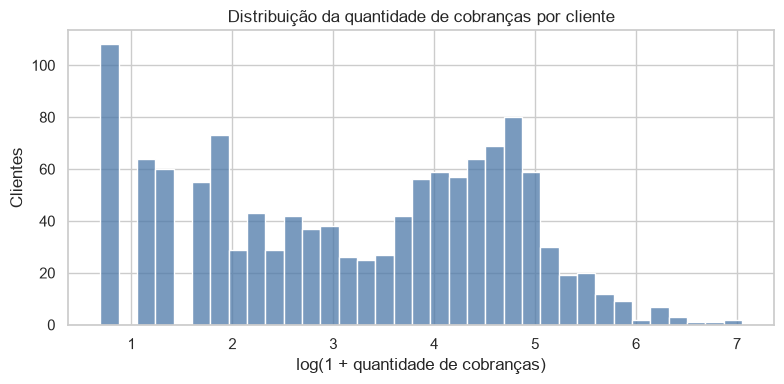

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(np.log1p(cobrancas_por_cliente), bins=35, color="#4C78A8", ax=ax)
ax.set(
    title="Distribuição da quantidade de cobranças por cliente",
    xlabel="log(1 + quantidade de cobranças)",
    ylabel="Clientes",
)
plt.tight_layout()
plt.show()

A mediana é de 28 cobranças por cliente, enquanto 1% dos clientes possui aproximadamente 468 cobranças ou mais. A cauda longa confirma a recorrência e a concentração desigual de registros. Dos 976 clientes do teste, 888 (90,98%) já aparecem no desenvolvimento; a avaliação futura deve considerar essa repetição sem confundir cobrança com cliente.

### 7.2. Distribuição do TARGET

O target indica pagamento com atraso de cinco dias ou mais. Contagem e proporção mostram a frequência do evento na base de desenvolvimento.

In [16]:
distribuicao_target_eda = (
    eda_dev["TARGET"]
    .value_counts()
    .sort_index()
    .rename_axis("TARGET")
    .to_frame("quantidade")
    .assign(percentual=lambda x: 100 * x["quantidade"] / x["quantidade"].sum())
)
distribuicao_target_eda

,quantidade,percentual
TARGET,,
0,71978,92.978014
1,5436,7.021986


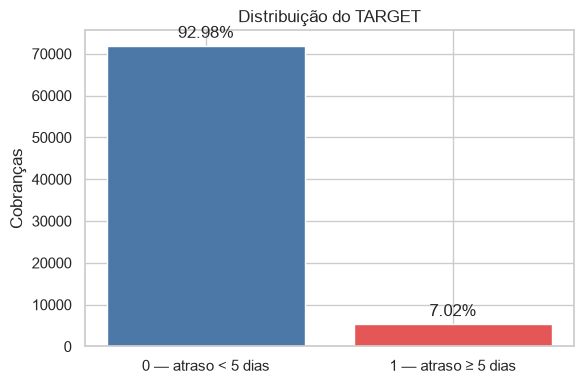

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(
    ["0 — atraso < 5 dias", "1 — atraso ≥ 5 dias"],
    distribuicao_target_eda["quantidade"],
    color=["#4C78A8", "#E45756"],
)
ax.bar_label(
    barras,
    labels=[f"{valor:.2f}%" for valor in distribuicao_target_eda["percentual"]],
    padding=3,
)
ax.set(title="Distribuição do TARGET", ylabel="Cobranças")
plt.tight_layout()
plt.show()

O evento ocorre em 5.436 das 77.414 cobranças (7,02%). Esse desbalanceamento torna pouco informativa uma avaliação baseada apenas em acurácia; métricas voltadas à ordenação e à qualidade das probabilidades deverão ser consideradas posteriormente. A EDA, isoladamente, não torna obrigatório o uso de reamostragem ou pesos de classe.

### 7.3. Evolução temporal

Quantidade de cobranças e taxa do target são agregadas por `SAFRA_DT`. As duas séries ajudam a verificar mudanças de volume e de frequência do evento ao longo do período observado.

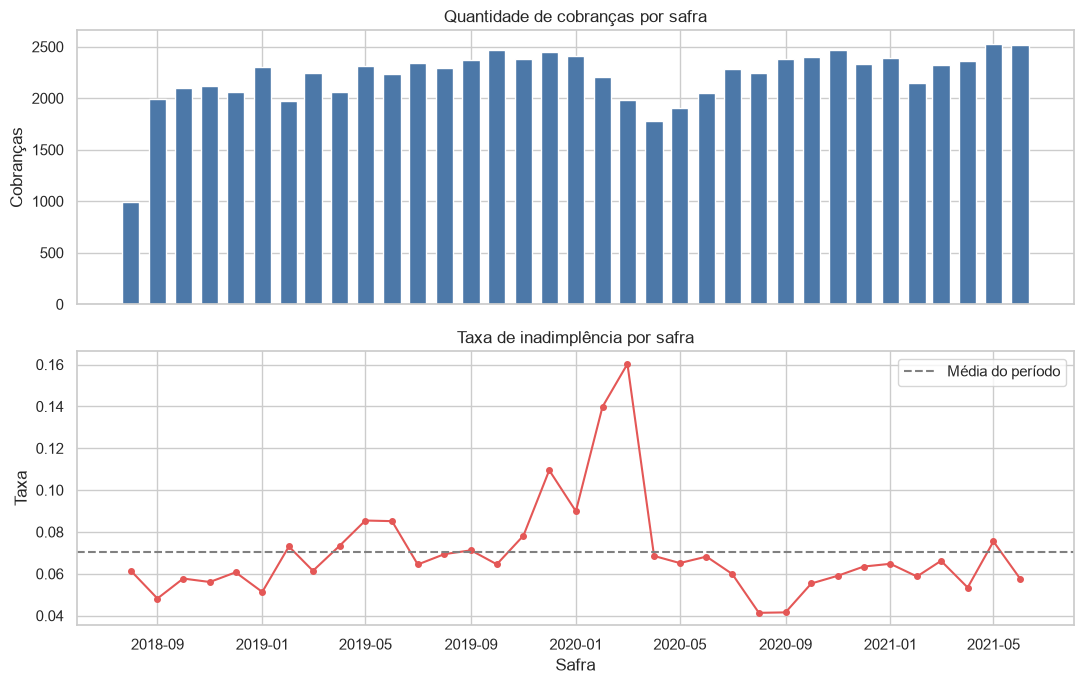

,SAFRA_DT,quantidade_cobrancas,taxa_inadimplencia
19,2020-03-01,1984,0.160282
24,2020-08-01,2249,0.041352


In [18]:
evolucao_mensal = (
    eda_dev.groupby("SAFRA_DT", as_index=False)
    .agg(
        quantidade_cobrancas=("TARGET", "size"),
        taxa_inadimplencia=("TARGET", "mean"),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].bar(
    evolucao_mensal["SAFRA_DT"],
    evolucao_mensal["quantidade_cobrancas"],
    width=20,
    color="#4C78A8",
)
axes[0].set(title="Quantidade de cobranças por safra", ylabel="Cobranças")

axes[1].plot(
    evolucao_mensal["SAFRA_DT"],
    evolucao_mensal["taxa_inadimplencia"],
    marker="o",
    markersize=4,
    color="#E45756",
)
axes[1].axhline(
    eda_dev["TARGET"].mean(),
    linestyle="--",
    color="gray",
    label="Média do período",
)
axes[1].set(
    title="Taxa de inadimplência por safra",
    xlabel="Safra",
    ylabel="Taxa",
)
axes[1].legend()

plt.tight_layout()
plt.show()

evolucao_mensal.loc[
    evolucao_mensal["taxa_inadimplencia"].isin(
        [
            evolucao_mensal["taxa_inadimplencia"].min(),
            evolucao_mensal["taxa_inadimplencia"].max(),
        ]
    )
]

A taxa mensal não é constante: varia de 4,14% em agosto de 2020 a 16,03% em março de 2020, enquanto o volume também muda entre safras. Essa variação observada indica que uma validação temporal será mais coerente com o teste, que ocorre depois do desenvolvimento. A estratégia de validação não é implementada nesta seção.

### 7.4. Valores ausentes

São apresentados apenas campos com ausência relevante para as análises ou para a modelagem. Em `FLAG_PF`, NaN possui significado de negócio: representa pessoa jurídica e foi convertido em `TIPO_PESSOA = PJ`, não em dado desconhecido.

In [19]:
colunas_missing_relevantes = [
    "FLAG_PF",
    "RENDA_MES_ANTERIOR",
    "NO_FUNCIONARIOS",
    "DDD",
    "PORTE",
    "SEGMENTO_INDUSTRIAL",
    "DOMINIO_EMAIL",
]

resumo_missing = pd.DataFrame(
    {
        "ausentes": eda_dev[colunas_missing_relevantes].isna().sum(),
        "percentual": 100 * eda_dev[colunas_missing_relevantes].isna().mean(),
    }
).sort_values("percentual", ascending=False)

resumo_tipo_pessoa = (
    eda_dev["TIPO_PESSOA"]
    .value_counts()
    .rename_axis("TIPO_PESSOA")
    .to_frame("registros")
)

display(resumo_missing)
resumo_tipo_pessoa

,ausentes,percentual
FLAG_PF,77195,99.717105
NO_FUNCIONARIOS,7587,9.800553
DDD,7414,9.577079
RENDA_MES_ANTERIOR,6132,7.921048
PORTE,2476,3.198388
SEGMENTO_INDUSTRIAL,1417,1.830418
DOMINIO_EMAIL,898,1.159997


,registros
TIPO_PESSOA,
PJ,77195
PF,219


In [20]:
comparacoes_missing = []

for coluna in ["RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS"]:
    comparacao = (
        eda_dev.assign(
            disponibilidade=np.where(
                eda_dev[coluna].notna(),
                "Com informação",
                "Sem informação",
            )
        )
        .groupby("disponibilidade", as_index=False)
        .agg(
            registros=("TARGET", "size"),
            taxa_inadimplencia=("TARGET", "mean"),
        )
    )
    comparacao.insert(0, "variavel", coluna)
    comparacoes_missing.append(comparacao)

comparacao_taxa_missing = pd.concat(comparacoes_missing, ignore_index=True)
comparacao_taxa_missing

,variavel,disponibilidade,registros,taxa_inadimplencia
0,RENDA_MES_ANTERIOR,Com informação,71282,0.069751
1,RENDA_MES_ANTERIOR,Sem informação,6132,0.075669
2,NO_FUNCIONARIOS,Com informação,69827,0.068942
3,NO_FUNCIONARIOS,Sem informação,7587,0.081982


Renda e número de funcionários estão ausentes em 7,92% e 9,80% das cobranças. A taxa do target é maior nos grupos sem informação: 7,57% contra 6,98% para renda e 8,20% contra 6,89% para funcionários. Trata-se de uma associação descritiva; a ausência deverá ser tratada no pré-processamento, sem interpretação causal.

### 7.5. Variáveis numéricas

A análise numérica se restringe a valor da cobrança, taxa, renda mensal anterior e número de funcionários. Quantis são preferidos a boxplots em escala bruta porque as variáveis financeiras possuem caudas longas.

In [21]:
variaveis_numericas_eda = [
    "VALOR_A_PAGAR",
    "TAXA",
    "RENDA_MES_ANTERIOR",
    "NO_FUNCIONARIOS",
]

estatisticas_numericas = (
    eda_dev[variaveis_numericas_eda]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .T
    .rename(
        columns={
            "25%": "Q1",
            "50%": "mediana",
            "75%": "Q3",
            "90%": "P90",
            "95%": "P95",
            "99%": "P99",
        }
    )
)
estatisticas_numericas

,count,mean,std,min,Q1,mediana,Q3,P90,P95,P99,max
VALOR_A_PAGAR,76244.0,46590.777166,46433.929580,0.10,18765.3625,34758.695,60933.8375,99390.42,128337.5645,189138.825,4400000.00
TAXA,77414.0,6.789623,1.798225,4.99,5.9900,5.990,6.9900,8.99,11.9900,11.990,11.99
RENDA_MES_ANTERIOR,71282.0,291438.084103,213293.159141,105.00,134074.2500,240502.000,396250.0000,581151.00,708436.9000,993664.000,1682759.00
NO_FUNCIONARIOS,69827.0,117.692812,18.779624,0.00,105.0000,118.000,130.0000,141.00,147.0000,161.000,198.00


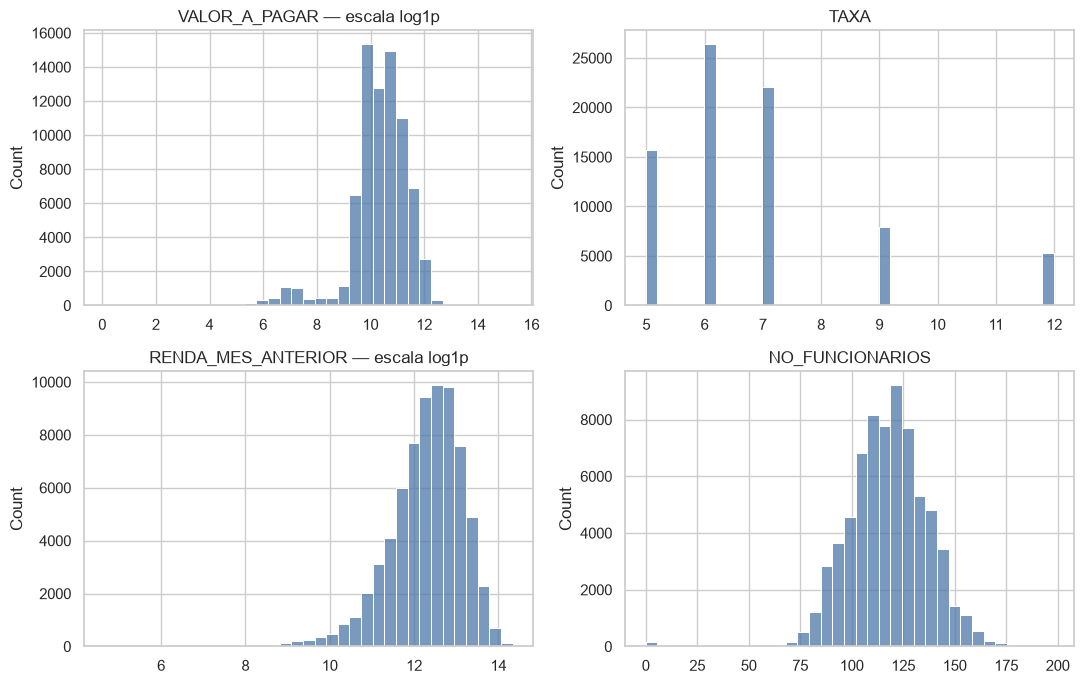

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

configuracao_distribuicoes = [
    ("VALOR_A_PAGAR", True),
    ("TAXA", False),
    ("RENDA_MES_ANTERIOR", True),
    ("NO_FUNCIONARIOS", False),
]

for ax, (coluna, usar_log) in zip(axes.flat, configuracao_distribuicoes):
    valores = eda_dev[coluna].dropna()
    valores_plot = np.log1p(valores) if usar_log else valores
    sns.histplot(valores_plot, bins=35, color="#4C78A8", ax=ax)
    sufixo = " — escala log1p" if usar_log else ""
    ax.set(title=f"{coluna}{sufixo}", xlabel="")

plt.tight_layout()
plt.show()

,variavel,quintil,registros,taxa_inadimplencia
0,VALOR_A_PAGAR,Q1,15249,0.175552
1,VALOR_A_PAGAR,Q2,15249,0.050889
2,VALOR_A_PAGAR,Q3,15248,0.044268
3,VALOR_A_PAGAR,Q4,15249,0.040003
4,VALOR_A_PAGAR,Q5,15249,0.038560
5,RENDA_MES_ANTERIOR,Q1,14260,0.109818
6,RENDA_MES_ANTERIOR,Q2,14255,0.078148
7,RENDA_MES_ANTERIOR,Q3,14269,0.059500
8,RENDA_MES_ANTERIOR,Q4,14247,0.053064
9,RENDA_MES_ANTERIOR,Q5,14251,0.048207


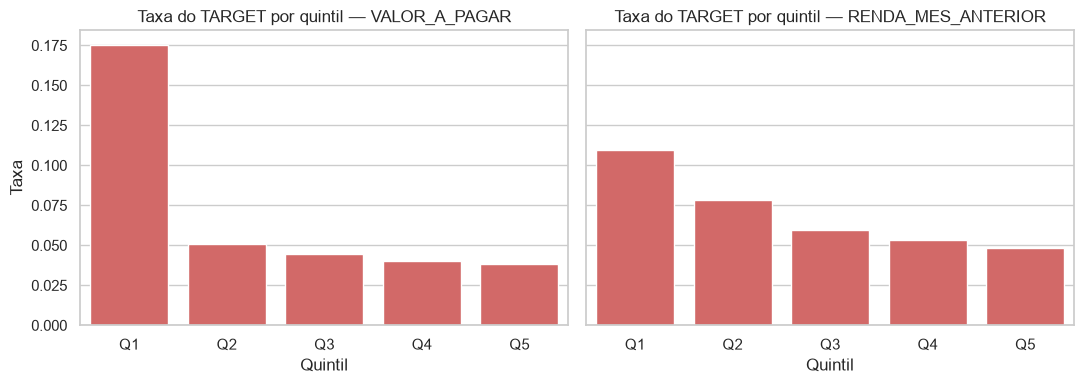

In [23]:
resumos_quintis = []

for coluna in ["VALOR_A_PAGAR", "RENDA_MES_ANTERIOR"]:
    dados_validos = eda_dev.loc[eda_dev[coluna].notna(), [coluna, "TARGET"]].copy()
    dados_validos["quintil"] = pd.qcut(
        dados_validos[coluna],
        q=5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
        duplicates="drop",
    )
    resumo = (
        dados_validos.groupby("quintil", observed=True, as_index=False)
        .agg(
            registros=("TARGET", "size"),
            taxa_inadimplencia=("TARGET", "mean"),
        )
    )
    resumo.insert(0, "variavel", coluna)
    resumos_quintis.append(resumo)

taxa_por_quintil = pd.concat(resumos_quintis, ignore_index=True)
display(taxa_por_quintil)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, coluna in zip(axes, ["VALOR_A_PAGAR", "RENDA_MES_ANTERIOR"]):
    dados_plot = taxa_por_quintil.loc[taxa_por_quintil["variavel"].eq(coluna)]
    sns.barplot(
        data=dados_plot,
        x="quintil",
        y="taxa_inadimplencia",
        color="#E45756",
        ax=ax,
    )
    ax.set(title=f"Taxa do TARGET por quintil — {coluna}", xlabel="Quintil", ylabel="Taxa")

plt.tight_layout()
plt.show()

`VALOR_A_PAGAR` alcança R$ 4,4 milhões, muito acima do terceiro quartil, e renda também apresenta forte assimetria. Valores extremos podem ser ocorrências legítimas do negócio e não são removidos automaticamente. No desenvolvimento, a taxa do target diminui ao longo dos quintis de valor e de renda; essa associação justifica avaliar essas variáveis na modelagem, mas não demonstra efeito causal.

### 7.6. Variáveis categóricas

Segmento industrial, porte e tipo de pessoa são resumidos por suporte e taxa do target. A quantidade de registros acompanha cada taxa para evitar interpretações baseadas em grupos muito pequenos.

In [24]:
def resumo_categorico(base, coluna):
    categoria = base[coluna].astype("object").where(base[coluna].notna(), "AUSENTE")
    return (
        base.assign(_CATEGORIA=categoria)
        .groupby("_CATEGORIA", as_index=False)
        .agg(
            registros=("TARGET", "size"),
            taxa_inadimplencia=("TARGET", "mean"),
        )
        .assign(variavel=coluna)
        [["variavel", "_CATEGORIA", "registros", "taxa_inadimplencia"]]
        .rename(columns={"_CATEGORIA": "categoria"})
        .sort_values(["variavel", "registros"], ascending=[True, False])
    )


resumo_categoricas = pd.concat(
    [
        resumo_categorico(eda_dev, coluna)
        for coluna in ["SEGMENTO_INDUSTRIAL", "PORTE", "TIPO_PESSOA"]
    ],
    ignore_index=True,
)

for coluna in ["SEGMENTO_INDUSTRIAL", "PORTE", "TIPO_PESSOA"]:
    display(resumo_categoricas.loc[resumo_categoricas["variavel"].eq(coluna)])

cardinalidade_adicional = eda_dev[
    ["DDD", "CEP_2_DIG", "DOMINIO_EMAIL"]
].nunique(dropna=True).rename("categorias_distintas").to_frame()
cardinalidade_adicional

,variavel,categoria,registros,taxa_inadimplencia
0,SEGMENTO_INDUSTRIAL,Serviços,31638,0.087458
1,SEGMENTO_INDUSTRIAL,Comércio,27062,0.045895
2,SEGMENTO_INDUSTRIAL,Indústria,17297,0.076487
3,SEGMENTO_INDUSTRIAL,AUSENTE,1417,0.073394


,variavel,categoria,registros,taxa_inadimplencia
4,PORTE,MEDIO,29929,0.064753
5,PORTE,GRANDE,29032,0.055112
6,PORTE,PEQUENO,15977,0.091694
7,PORTE,AUSENTE,2476,0.174879


,variavel,categoria,registros,taxa_inadimplencia
8,TIPO_PESSOA,PJ,77195,0.069849
9,TIPO_PESSOA,PF,219,0.200913


,categorias_distintas
DDD,78
CEP_2_DIG,90
DOMINIO_EMAIL,6


Serviços, comércio e indústria possuem suporte suficiente para comparação descritiva. Em porte, a categoria ausente tem taxa maior, mas representa 2.476 registros e deve ser tratada como ausência, não como porte conhecido. Pessoa física reúne apenas 219 cobranças; sua taxa não deve ser destacada sem considerar esse suporte reduzido. DDD, CEP e domínio de e-mail têm maior cardinalidade e não são detalhados nesta EDA.

### 7.7. Comparação entre desenvolvimento e teste

A comparação utiliza apenas atributos, sem target no teste. Mediana, quartis e ausência permitem identificar diferenças simples de nível e cobertura.

In [25]:
comparacao_numerica = []

for nome_base, base in [("Desenvolvimento", eda_dev), ("Teste", eda_test)]:
    for coluna in variaveis_numericas_eda:
        serie = base[coluna]
        comparacao_numerica.append(
            {
                "base": nome_base,
                "variavel": coluna,
                "Q1": serie.quantile(0.25),
                "mediana": serie.median(),
                "Q3": serie.quantile(0.75),
                "percentual_missing": 100 * serie.isna().mean(),
            }
        )

comparacao_numerica = pd.DataFrame(comparacao_numerica)
comparacao_numerica

,base,variavel,Q1,mediana,Q3,percentual_missing
0,Desenvolvimento,VALOR_A_PAGAR,18765.3625,34758.695,60933.8375,1.511355
1,Desenvolvimento,TAXA,5.9900,5.990,6.9900,0.000000
2,Desenvolvimento,RENDA_MES_ANTERIOR,134074.2500,240502.000,396250.0000,7.921048
3,Desenvolvimento,NO_FUNCIONARIOS,105.0000,118.000,130.0000,9.800553
4,Teste,VALOR_A_PAGAR,26712.3350,49665.210,87029.3625,1.067210
5,Teste,TAXA,5.9900,5.990,6.9900,0.000000
6,Teste,RENDA_MES_ANTERIOR,137543.0000,249907.000,397263.0000,5.914460
7,Teste,NO_FUNCIONARIOS,114.0000,126.000,138.0000,9.507128


In [26]:
colunas_categoricas_comparacao = [
    "SEGMENTO_INDUSTRIAL",
    "PORTE",
    "TIPO_PESSOA",
    "DDD",
    "CEP_2_DIG",
    "DOMINIO_EMAIL",
]

categorias_novas_teste = []
for coluna in colunas_categoricas_comparacao:
    categorias_dev = set(eda_dev[coluna].dropna().astype(str))
    categorias_test = set(eda_test[coluna].dropna().astype(str))
    novas = sorted(categorias_test - categorias_dev)
    categorias_novas_teste.append(
        {
            "variavel": coluna,
            "quantidade_categorias_novas": len(novas),
            "categorias_novas": novas,
        }
    )

categorias_novas_teste = pd.DataFrame(categorias_novas_teste)
categorias_novas_teste

,variavel,quantidade_categorias_novas,categorias_novas
0,SEGMENTO_INDUSTRIAL,0,[]
1,PORTE,0,[]
2,TIPO_PESSOA,0,[]
3,DDD,1,[(7]
4,CEP_2_DIG,0,[]
5,DOMINIO_EMAIL,0,[]


O teste apresenta mediana maior de valor a pagar (R$ 49,7 mil contra R$ 34,8 mil) e de número de funcionários (126 contra 118). Taxa e renda têm estatísticas centrais mais próximas. Entre as categorias verificadas, somente DDD contém uma categoria observada apenas no teste. Essas diferenças não provam drift, mas sustentam imputação consistente e tratamento de categorias não vistas.

### 7.8. Correlação linear

A correlação de Pearson é apresentada apenas como resumo das associações lineares entre as quatro variáveis numéricas. Ela não captura relações não lineares e não estabelece independência.

In [27]:
correlacao_numericas = eda_dev[variaveis_numericas_eda].corr()
correlacao_numericas

,VALOR_A_PAGAR,TAXA,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
VALOR_A_PAGAR,1.000000,-0.013150,0.003954,0.028722
TAXA,-0.013150,1.000000,0.003919,0.013834
RENDA_MES_ANTERIOR,0.003954,0.003919,1.000000,0.028647
NO_FUNCIONARIOS,0.028722,0.013834,0.028647,1.000000


Não foram observadas associações lineares fortes entre as variáveis numéricas analisadas. Isso não implica independência estatística nem permite concluir qual será a contribuição de cada variável no modelo.

### 7.9. Síntese da EDA

Os achados abaixo conectam evidências observadas a decisões que serão tratadas nas etapas posteriores, sem antecipar resultados de modelos.

In [28]:
sintese_eda = pd.DataFrame(
    {
        "ACHADO": [
            "Apenas 7,02% das cobranças possuem TARGET = 1.",
            "A taxa mensal varia ao longo do desenvolvimento.",
            "Clientes possuem múltiplas cobranças e 90,98% dos clientes do teste já aparecem no desenvolvimento.",
            "Valor a pagar e renda possuem distribuições assimétricas e valores extremos.",
            "Renda e número de funcionários possuem valores ausentes.",
            "O teste apresenta valores centrais maiores para valor a pagar e número de funcionários.",
            "Uma categoria de DDD aparece somente no teste.",
        ],
        "IMPLICAÇÃO PARA A MODELAGEM": [
            "Avaliar probabilidades com métricas adequadas ao desbalanceamento.",
            "Preferir uma avaliação que respeite a ordem temporal.",
            "Evitar assumir independência entre cobranças do mesmo cliente na validação.",
            "Usar transformações robustas quando necessárias, sem remoção automática de extremos.",
            "Ajustar a imputação somente com os dados de treino.",
            "Interpretar a validação considerando possíveis diferenças de distribuição.",
            "Usar codificação capaz de lidar com categorias não observadas no treino.",
        ],
    }
)
sintese_eda

,ACHADO,IMPLICAÇÃO PARA A MODELAGEM
0,"Apenas 7,02% das cobranças possuem TARGET = 1.",Avaliar probabilidades com métricas adequadas ...
1,A taxa mensal varia ao longo do desenvolvimento.,Preferir uma avaliação que respeite a ordem te...
2,"Clientes possuem múltiplas cobranças e 90,98% ...",Evitar assumir independência entre cobranças d...
3,Valor a pagar e renda possuem distribuições as...,Usar transformações robustas quando necessária...
4,Renda e número de funcionários possuem valores...,Ajustar a imputação somente com os dados de tr...
5,O teste apresenta valores centrais maiores par...,Interpretar a validação considerando possíveis...
6,Uma categoria de DDD aparece somente no teste.,Usar codificação capaz de lidar com categorias...


A EDA identifica riscos metodológicos e características relevantes, mas não determina antecipadamente o melhor algoritmo. O efeito das decisões de preparação deve ser avaliado na etapa de validação.

## 8. Engenharia de atributos

Esta seção cria um conjunto pequeno de atributos disponíveis no momento da cobrança. São usados calendário, prazo, tempo de relacionamento, razões financeiras e histórico anterior do cliente. Nenhuma transformação é interpretada como causal e seu valor preditivo só poderá ser avaliado na comparação de modelos.

### 8.1. Escala da taxa e revisão de `TAXA_RELATIVA`

Antes de criar combinações financeiras, é necessário verificar como `TAXA` está armazenada. O produto `TAXA * VALOR_A_PAGAR` da versão anterior foi chamado de “taxa relativa”, embora não representasse uma razão.

In [29]:
resumo_taxa = (
    dev_full["TAXA"]
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .rename("TAXA")
    .to_frame()
)
resumo_taxa.loc["valores_distintos", "TAXA"] = dev_full["TAXA"].nunique()
resumo_taxa

,TAXA
count,77414.000000
mean,6.789623
std,1.798225
min,4.990000
1%,4.990000
25%,5.990000
50%,5.990000
75%,6.990000
99%,11.990000
max,11.990000


`TAXA` varia de 4,99 a 11,99 e possui cinco valores distintos. Ela não está armazenada como fração entre 0 e 1. Sem informação adicional sobre unidade e período, multiplicá-la pelo valor da cobrança produz uma grandeza ambígua, não uma medida relativa. Portanto, `TAXA_RELATIVA` é removida e `TAXA` permanece como atributo original.

### 8.2. Features da cobrança e do cadastro

Ano e mês representam o período de referência. Prazo e tempo de cadastro usam somente datas conhecidas até a emissão. As duas razões comparam o valor da cobrança com capacidade financeira e estrutura da empresa; denominadores iguais a zero geram ausência, não infinito. Essas razões podem ser instáveis para denominadores pequenos e não devem receber interpretação causal.

In [30]:
def criar_features_atuais(base):
    features = base.copy()

    colunas_necessarias = {
        "SAFRA_DT",
        "DATA_EMISSAO_DOCUMENTO",
        "DATA_VENCIMENTO",
        "DATA_CADASTRO",
        "VALOR_A_PAGAR",
        "RENDA_MES_ANTERIOR",
        "NO_FUNCIONARIOS",
        "FLAG_PF",
    }
    faltantes = colunas_necessarias - set(features.columns)
    assert not faltantes, f"Colunas necessárias ausentes: {sorted(faltantes)}"

    features["SAFRA_ANO"] = features["SAFRA_DT"].dt.year
    features["SAFRA_MES"] = features["SAFRA_DT"].dt.month
    features["PRAZO_EMISSAO_VENCIMENTO_DIAS"] = (
        features["DATA_VENCIMENTO"] - features["DATA_EMISSAO_DOCUMENTO"]
    ).dt.days
    features["TEMPO_CADASTRO_DIAS"] = (
        features["DATA_EMISSAO_DOCUMENTO"] - features["DATA_CADASTRO"]
    ).dt.days

    renda_valida = features["RENDA_MES_ANTERIOR"].replace(0, np.nan)
    funcionarios_validos = features["NO_FUNCIONARIOS"].replace(0, np.nan)
    features["VALOR_SOBRE_RENDA"] = features["VALOR_A_PAGAR"] / renda_valida
    features["VALOR_POR_FUNCIONARIO"] = (
        features["VALOR_A_PAGAR"] / funcionarios_validos
    )

    colunas_razao = ["VALOR_SOBRE_RENDA", "VALOR_POR_FUNCIONARIO"]
    features[colunas_razao] = features[colunas_razao].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # Conforme o dicionário: X = pessoa física; NaN = pessoa jurídica.
    features["TIPO_PESSOA"] = np.where(features["FLAG_PF"].eq("X"), "PF", "PJ")
    return features


dev_features = criar_features_atuais(dev_full)
test_features = criar_features_atuais(test_full)

In [31]:
validacao_features_atuais = pd.DataFrame(
    {
        "base": ["desenvolvimento", "teste"],
        "prazo_negativo": [
            dev_features["PRAZO_EMISSAO_VENCIMENTO_DIAS"].lt(0).sum(),
            test_features["PRAZO_EMISSAO_VENCIMENTO_DIAS"].lt(0).sum(),
        ],
        "tempo_cadastro_negativo": [
            dev_features["TEMPO_CADASTRO_DIAS"].lt(0).sum(),
            test_features["TEMPO_CADASTRO_DIAS"].lt(0).sum(),
        ],
        "infinito_valor_sobre_renda": [
            np.isinf(dev_features["VALOR_SOBRE_RENDA"]).sum(),
            np.isinf(test_features["VALOR_SOBRE_RENDA"]).sum(),
        ],
        "infinito_valor_por_funcionario": [
            np.isinf(dev_features["VALOR_POR_FUNCIONARIO"]).sum(),
            np.isinf(test_features["VALOR_POR_FUNCIONARIO"]).sum(),
        ],
    }
)
validacao_features_atuais

,base,prazo_negativo,tempo_cadastro_negativo,infinito_valor_sobre_renda,infinito_valor_por_funcionario
0,desenvolvimento,27,40,0,0
1,teste,2,0,0,0


Há 27 prazos negativos e 40 tempos de cadastro negativos no desenvolvimento. Esses casos são mantidos e registrados como inconsistências, pois não existe uma regra de correção no dicionário. As razões não contêm infinitos; valores estruturalmente indefinidos permanecem como NaN para tratamento posterior no pipeline.

### 8.3. Histórico anterior por cliente e safra

O histórico é calculado primeiro na granularidade `ID_CLIENTE`–`SAFRA_DT`. Quantidades da safra são acumuladas e depois deslocadas em um mês dentro de cada cliente. Assim, todas as cobranças de uma mesma safra recebem o mesmo retrato, e o target da safra atual não participa de suas próprias features.

In [32]:
historico_mensal = (
    base_dev.groupby(["ID_CLIENTE", "SAFRA_DT"], as_index=False)
    .agg(
        _QTD_COBRANCAS_SAFRA=("TARGET", "size"),
        _QTD_INADIMPLENCIAS_SAFRA=("TARGET", "sum"),
    )
    .sort_values(["ID_CLIENTE", "SAFRA_DT"])
    .reset_index(drop=True)
)

grupo_cliente = historico_mensal.groupby("ID_CLIENTE", sort=False)
historico_mensal["_ACUM_COBRANCAS"] = grupo_cliente[
    "_QTD_COBRANCAS_SAFRA"
].cumsum()
historico_mensal["_ACUM_INADIMPLENCIAS"] = grupo_cliente[
    "_QTD_INADIMPLENCIAS_SAFRA"
].cumsum()

# O shift ocorre depois da agregação mensal e dentro de cada cliente.
historico_mensal["HIST_QTD_COBRANCAS"] = grupo_cliente[
    "_ACUM_COBRANCAS"
].shift(1)
historico_mensal["HIST_QTD_INADIMPLENCIAS"] = grupo_cliente[
    "_ACUM_INADIMPLENCIAS"
].shift(1)

historico_mensal["FLAG_SEM_HISTORICO"] = (
    historico_mensal["HIST_QTD_COBRANCAS"].isna().astype("int8")
)

# Zero é um valor estrutural para contagens quando não existe mês anterior.
historico_mensal["HIST_QTD_COBRANCAS"] = (
    historico_mensal["HIST_QTD_COBRANCAS"].fillna(0).astype("int64")
)
historico_mensal["HIST_QTD_INADIMPLENCIAS"] = (
    historico_mensal["HIST_QTD_INADIMPLENCIAS"].fillna(0).astype("int64")
)
historico_mensal["HIST_TAXA_INADIMPLENCIA"] = (
    historico_mensal["HIST_QTD_INADIMPLENCIAS"]
    / historico_mensal["HIST_QTD_COBRANCAS"].replace(0, np.nan)
)

colunas_historicas = [
    "HIST_QTD_COBRANCAS",
    "HIST_QTD_INADIMPLENCIAS",
    "HIST_TAXA_INADIMPLENCIA",
    "FLAG_SEM_HISTORICO",
]

dev_features = dev_features.merge(
    historico_mensal[["ID_CLIENTE", "SAFRA_DT"] + colunas_historicas],
    on=["ID_CLIENTE", "SAFRA_DT"],
    how="left",
    sort=False,
    validate="many_to_one",
)

assert len(dev_features) == len(dev_full)

No desenvolvimento, ausência de histórico tem significado próprio: contagens recebem zero, `FLAG_SEM_HISTORICO` recebe 1 e a taxa permanece NaN. A taxa será imputada pela mediana aprendida exclusivamente no treino; a flag permite distinguir esse caso de um histórico observado sem inadimplência.

### 8.4. Histórico aplicado ao teste

Como não existem pagamentos observados no teste, todas as suas safras recebem um retrato fixo calculado com o desenvolvimento completo. As previsões não atualizam o histórico. Clientes inéditos recebem contagens zero, flag igual a 1 e taxa ausente para imputação posterior.

In [33]:
snapshot_dev = (
    historico_mensal.groupby("ID_CLIENTE", as_index=False)
    .agg(
        HIST_QTD_COBRANCAS=("_QTD_COBRANCAS_SAFRA", "sum"),
        HIST_QTD_INADIMPLENCIAS=("_QTD_INADIMPLENCIAS_SAFRA", "sum"),
    )
)
snapshot_dev["HIST_TAXA_INADIMPLENCIA"] = (
    snapshot_dev["HIST_QTD_INADIMPLENCIAS"]
    / snapshot_dev["HIST_QTD_COBRANCAS"].replace(0, np.nan)
)
snapshot_dev["FLAG_SEM_HISTORICO"] = 0

test_features = test_features.merge(
    snapshot_dev[["ID_CLIENTE"] + colunas_historicas],
    on="ID_CLIENTE",
    how="left",
    sort=False,
    validate="many_to_one",
)

sem_historico_teste = test_features["HIST_QTD_COBRANCAS"].isna()
test_features.loc[sem_historico_teste, "HIST_QTD_COBRANCAS"] = 0
test_features.loc[sem_historico_teste, "HIST_QTD_INADIMPLENCIAS"] = 0
test_features.loc[sem_historico_teste, "FLAG_SEM_HISTORICO"] = 1

test_features["HIST_QTD_COBRANCAS"] = (
    test_features["HIST_QTD_COBRANCAS"].astype("int64")
)
test_features["HIST_QTD_INADIMPLENCIAS"] = (
    test_features["HIST_QTD_INADIMPLENCIAS"].astype("int64")
)
test_features["FLAG_SEM_HISTORICO"] = (
    test_features["FLAG_SEM_HISTORICO"].astype("int8")
)

assert len(test_features) == len(test_full)
assert test_features["_ROW_ID"].tolist() == test_full["_ROW_ID"].tolist()

### 8.5. Testes contra vazamento

Os testes abaixo verificam a fronteira temporal do histórico na granularidade mensal e sua devolução às cobranças. Eles também confirmam que nenhuma coluna de pagamento ou target do teste participa da construção.

In [34]:
# Posição temporal de cada cliente no agregado mensal.
historico_mensal["_ORDEM_MES_CLIENTE"] = historico_mensal.groupby(
    "ID_CLIENTE"
).cumcount()

# 1) O primeiro mês não possui histórico.
primeiro_mes = historico_mensal["_ORDEM_MES_CLIENTE"].eq(0)
assert historico_mensal.loc[primeiro_mes, "HIST_QTD_COBRANCAS"].eq(0).all()
assert historico_mensal.loc[
    primeiro_mes, "HIST_QTD_INADIMPLENCIAS"
].eq(0).all()
assert historico_mensal.loc[primeiro_mes, "FLAG_SEM_HISTORICO"].eq(1).all()
assert historico_mensal.loc[
    primeiro_mes, "HIST_TAXA_INADIMPLENCIA"
].isna().all()

# 2) O segundo mês utiliza somente as quantidades do primeiro.
qtd_mes_anterior = historico_mensal.groupby("ID_CLIENTE")[
    "_QTD_COBRANCAS_SAFRA"
].shift(1)
inad_mes_anterior = historico_mensal.groupby("ID_CLIENTE")[
    "_QTD_INADIMPLENCIAS_SAFRA"
].shift(1)
segundo_mes = historico_mensal["_ORDEM_MES_CLIENTE"].eq(1)
assert historico_mensal.loc[
    segundo_mes, "HIST_QTD_COBRANCAS"
].equals(qtd_mes_anterior.loc[segundo_mes].astype("int64"))
assert historico_mensal.loc[
    segundo_mes, "HIST_QTD_INADIMPLENCIAS"
].equals(inad_mes_anterior.loc[segundo_mes].astype("int64"))

# 3) A própria safra não participa do histórico acumulado.
qtd_anterior_esperada = (
    historico_mensal.groupby("ID_CLIENTE")["_QTD_COBRANCAS_SAFRA"].cumsum()
    - historico_mensal["_QTD_COBRANCAS_SAFRA"]
)
inad_anterior_esperada = (
    historico_mensal.groupby("ID_CLIENTE")[
        "_QTD_INADIMPLENCIAS_SAFRA"
    ].cumsum()
    - historico_mensal["_QTD_INADIMPLENCIAS_SAFRA"]
)
assert historico_mensal["HIST_QTD_COBRANCAS"].equals(
    qtd_anterior_esperada.astype("int64")
)
assert historico_mensal["HIST_QTD_INADIMPLENCIAS"].equals(
    inad_anterior_esperada.astype("int64")
)

# 4) Todas as cobranças do cliente-safra recebem os mesmos valores.
max_variacoes_grupo = (
    dev_features.groupby(["ID_CLIENTE", "SAFRA_DT"])[colunas_historicas]
    .nunique(dropna=False)
    .max()
)
assert max_variacoes_grupo.le(1).all()

# 5) O teste não fornece pagamento ou target e não atualiza o snapshot.
assert {"DATA_PAGAMENTO", "TARGET"}.isdisjoint(base_test.columns)
assert {"DATA_PAGAMENTO", "TARGET"}.isdisjoint(test_features.columns)
assert test_features["HIST_QTD_COBRANCAS"].notna().all()
assert test_features["HIST_QTD_INADIMPLENCIAS"].notna().all()

clientes_ineditos = ~test_features["ID_CLIENTE"].isin(base_dev["ID_CLIENTE"])
assert test_features.loc[
    clientes_ineditos, "FLAG_SEM_HISTORICO"
].eq(1).all()
assert test_features.loc[
    clientes_ineditos, ["HIST_QTD_COBRANCAS", "HIST_QTD_INADIMPLENCIAS"]
].eq(0).all().all()
assert test_features.loc[
    clientes_ineditos, "HIST_TAXA_INADIMPLENCIA"
].isna().all()

pd.Series(
    {
        "primeiro_mês_sem_histórico": True,
        "segundo_mês_usa_somente_o_primeiro": True,
        "safra_atual_excluída_dos_acumulados": True,
        "histórico_constante_no_cliente_safra": True,
        "teste_sem_pagamento_ou_target": True,
        "clientes_inéditos_sinalizados": True,
        "clientes_inéditos_no_teste": int(
            test_features.loc[clientes_ineditos, "ID_CLIENTE"].nunique()
        ),
    }
)

primeiro_mês_sem_histórico              True
segundo_mês_usa_somente_o_primeiro      True
safra_atual_excluída_dos_acumulados     True
histórico_constante_no_cliente_safra    True
teste_sem_pagamento_ou_target           True
clientes_inéditos_sinalizados           True
clientes_inéditos_no_teste                88
dtype: object

Os asserts cobrem os casos de primeiro e segundo mês, comparam os acumulados ao total estritamente anterior e verificam a constância dentro do cliente-safra. O teste permanece sem qualquer atualização baseada em previsão ou resultado futuro.

## 9. Seleção de atributos e pré-processamento

As listas abaixo tornam explícito o que entra no modelo e o que fica excluído. Identificadores, datas brutas e colunas usadas para construir o desfecho não são preditores diretos.

In [35]:
numeric_features = [
    "SAFRA_ANO",
    "SAFRA_MES",
    "VALOR_A_PAGAR",
    "TAXA",
    "RENDA_MES_ANTERIOR",
    "NO_FUNCIONARIOS",
    "PRAZO_EMISSAO_VENCIMENTO_DIAS",
    "TEMPO_CADASTRO_DIAS",
    "VALOR_SOBRE_RENDA",
    "VALOR_POR_FUNCIONARIO",
    "HIST_QTD_COBRANCAS",
    "HIST_QTD_INADIMPLENCIAS",
    "HIST_TAXA_INADIMPLENCIA",
    "FLAG_SEM_HISTORICO",
]

categorical_features = [
    "DDD",
    "SEGMENTO_INDUSTRIAL",
    "DOMINIO_EMAIL",
    "PORTE",
    "CEP_2_DIG",
    "TIPO_PESSOA",
]

excluded_features = [
    "ID_CLIENTE",
    "SAFRA_REF",
    "SAFRA_DT",
    "DATA_CADASTRO",
    "DATA_EMISSAO_DOCUMENTO",
    "DATA_VENCIMENTO",
    "DATA_PAGAMENTO",
    "DIAS_ATRASO",
    "TARGET",
    "_ROW_ID",
    "FLAG_PF",
]

proibidas = {
    "ID_CLIENTE",
    "DATA_PAGAMENTO",
    "DIAS_ATRASO",
    "TARGET",
    "_ROW_ID",
    "DATA_CADASTRO",
    "DATA_EMISSAO_DOCUMENTO",
    "DATA_VENCIMENTO",
}
assert proibidas.isdisjoint(numeric_features + categorical_features)
assert set(numeric_features + categorical_features).issubset(dev_features.columns)
assert set(numeric_features + categorical_features).issubset(test_features.columns)

# Normaliza apenas o marcador de ausência; nenhum valor é imputado aqui.
for coluna in categorical_features:
    dev_features[coluna] = (
        dev_features[coluna].astype("object").where(dev_features[coluna].notna(), np.nan)
    )
    test_features[coluna] = (
        test_features[coluna].astype("object").where(test_features[coluna].notna(), np.nan)
    )

y = dev_features["TARGET"].copy()
X = dev_features[numeric_features + categorical_features].copy()
X_test = test_features[numeric_features + categorical_features].copy()

assert X.columns.tolist() == X_test.columns.tolist()
assert proibidas.isdisjoint(X.columns)

pd.DataFrame(
    {
        "grupo": ["numéricas", "categóricas", "excluídas"],
        "quantidade": [
            len(numeric_features),
            len(categorical_features),
            len(excluded_features),
        ],
        "colunas": [
            numeric_features,
            categorical_features,
            excluded_features,
        ],
    }
)

,grupo,quantidade,colunas
0,numéricas,14,"[SAFRA_ANO, SAFRA_MES, VALOR_A_PAGAR, TAXA, RE..."
1,categóricas,6,"[DDD, SEGMENTO_INDUSTRIAL, DOMINIO_EMAIL, PORT..."
2,excluídas,11,"[ID_CLIENTE, SAFRA_REF, SAFRA_DT, DATA_CADASTR..."


A imputação não é feita em `dev_features`, `test_features`, `X` ou `X_test`. Ela permanece dentro do pipeline para que medianas e categorias sejam aprendidas somente após a divisão treino-validação. `ID_CLIENTE` é usado exclusivamente para construir o histórico anterior e não entra como feature direta.

### 9.1. Duas versões do pré-processador

A regressão logística recebe imputação mediana e padronização numérica, pois sua otimização é sensível às escalas. Modelos de árvore recebem a mesma imputação, sem `StandardScaler`. Nas duas versões, categorias são imputadas por uma constante e codificadas com tratamento para níveis não observados.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_pipeline_linear = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline_linear = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="AUSENTE")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_pipeline_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)
categorical_pipeline_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="AUSENTE")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline_linear, numeric_features),
        ("categorical", categorical_pipeline_linear, categorical_features),
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline_tree, numeric_features),
        ("categorical", categorical_pipeline_tree, categorical_features),
    ]
)

print("Pré-processadores criados, ainda não ajustados:")
print("- preprocessor_linear: imputação + escala + one-hot")
print("- preprocessor_tree: imputação + one-hot, sem escala")

Pré-processadores criados, ainda não ajustados:
- preprocessor_linear: imputação + escala + one-hot
- preprocessor_tree: imputação + one-hot, sem escala


Os dois objetos estão apenas configurados; nenhum `fit` foi executado nesta seção. Isso evita que estatísticas do futuro ou da validação sejam incorporadas antes da divisão dos dados.

### 9.2. Validação da seção

Foram criadas sete features atuais e quatro históricas. `TAXA_RELATIVA` foi removida, valores ausentes não foram preenchidos fora dos pipelines e as colunas de desenvolvimento e teste estão alinhadas para as etapas seguintes.

In [37]:
features_atuais_criadas = [
    "SAFRA_ANO",
    "SAFRA_MES",
    "PRAZO_EMISSAO_VENCIMENTO_DIAS",
    "TEMPO_CADASTRO_DIAS",
    "VALOR_SOBRE_RENDA",
    "VALOR_POR_FUNCIONARIO",
    "TIPO_PESSOA",
]

assert set(features_atuais_criadas + colunas_historicas).issubset(
    dev_features.columns
)
assert "TAXA_RELATIVA" not in dev_features.columns
assert "TAXA_RELATIVA" not in test_features.columns
assert not np.isinf(
    dev_features[["VALOR_SOBRE_RENDA", "VALOR_POR_FUNCIONARIO"]]
    .select_dtypes(include="number")
    .to_numpy()
).any()
assert not np.isinf(
    test_features[["VALOR_SOBRE_RENDA", "VALOR_POR_FUNCIONARIO"]]
    .select_dtypes(include="number")
    .to_numpy()
).any()

pd.Series(
    {
        "features_atuais_criadas": len(features_atuais_criadas),
        "features_historicas_criadas": len(colunas_historicas),
        "features_numericas_modelo": len(numeric_features),
        "features_categoricas_modelo": len(categorical_features),
        "linhas_desenvolvimento_preservadas": len(dev_features) == len(dev_full),
        "linhas_teste_preservadas": len(test_features) == len(test_full),
        "ordem_teste_preservada": (
            test_features["_ROW_ID"].tolist() == test_full["_ROW_ID"].tolist()
        ),
        "taxa_relativa_removida": "TAXA_RELATIVA" not in dev_features.columns,
    }
)

features_atuais_criadas                  7
features_historicas_criadas              4
features_numericas_modelo               14
features_categoricas_modelo              6
linhas_desenvolvimento_preservadas    True
linhas_teste_preservadas              True
ordem_teste_preservada                True
taxa_relativa_removida                True
dtype: object

## 10. Divisão temporal entre treino e validação

As safras são ordenadas cronologicamente. As três últimas safras do desenvolvimento formam a validação, e todas as anteriores formam o treino. Essa configuração aproxima a avaliação do uso esperado: ajustar o modelo com o passado e prever cobranças futuras.

In [38]:
safras_ordenadas = sorted(dev_features["SAFRA_DT"].dropna().unique())
SAFRAS_VALIDACAO = safras_ordenadas[-3:]
INICIO_VALIDACAO = SAFRAS_VALIDACAO[0]

train = dev_features.loc[
    dev_features["SAFRA_DT"] < INICIO_VALIDACAO
].copy()
valid = dev_features.loc[
    dev_features["SAFRA_DT"].isin(SAFRAS_VALIDACAO)
].copy()

assert len(SAFRAS_VALIDACAO) == 3
assert len(train) + len(valid) == len(dev_features)
assert train["SAFRA_DT"].max() < valid["SAFRA_DT"].min()

Para espelhar a base de teste, o histórico das três safras de validação é congelado no fim do treino. Targets de abril, maio ou junho de 2021 não atualizam as features de outras linhas da validação.

In [39]:
snapshot_train = (
    base_dev.loc[base_dev["SAFRA_DT"] < INICIO_VALIDACAO]
    .groupby("ID_CLIENTE", as_index=False)
    .agg(
        HIST_QTD_COBRANCAS=("TARGET", "size"),
        HIST_QTD_INADIMPLENCIAS=("TARGET", "sum"),
    )
)
snapshot_train["HIST_TAXA_INADIMPLENCIA"] = (
    snapshot_train["HIST_QTD_INADIMPLENCIAS"]
    / snapshot_train["HIST_QTD_COBRANCAS"].replace(0, np.nan)
)
snapshot_train["FLAG_SEM_HISTORICO"] = 0

valid = valid.drop(columns=colunas_historicas).merge(
    snapshot_train[["ID_CLIENTE"] + colunas_historicas],
    on="ID_CLIENTE",
    how="left",
    sort=False,
    validate="many_to_one",
)

sem_historico_valid = valid["HIST_QTD_COBRANCAS"].isna()
valid.loc[sem_historico_valid, "HIST_QTD_COBRANCAS"] = 0
valid.loc[sem_historico_valid, "HIST_QTD_INADIMPLENCIAS"] = 0
valid.loc[sem_historico_valid, "FLAG_SEM_HISTORICO"] = 1

valid["HIST_QTD_COBRANCAS"] = valid["HIST_QTD_COBRANCAS"].astype("int64")
valid["HIST_QTD_INADIMPLENCIAS"] = valid[
    "HIST_QTD_INADIMPLENCIAS"
].astype("int64")
valid["FLAG_SEM_HISTORICO"] = valid["FLAG_SEM_HISTORICO"].astype("int8")

assert len(valid) == dev_features["SAFRA_DT"].isin(SAFRAS_VALIDACAO).sum()
assert train["SAFRA_DT"].max() < valid["SAFRA_DT"].min()

In [40]:
X_train = train[numeric_features + categorical_features].copy()
y_train = train["TARGET"].copy()
X_valid = valid[numeric_features + categorical_features].copy()
y_valid = valid["TARGET"].copy()

resumo_holdout = pd.DataFrame(
    {
        "conjunto": ["treino", "validação"],
        "periodo_inicial": [
            train["SAFRA_DT"].min(),
            valid["SAFRA_DT"].min(),
        ],
        "periodo_final": [
            train["SAFRA_DT"].max(),
            valid["SAFRA_DT"].max(),
        ],
        "linhas": [len(train), len(valid)],
        "clientes": [
            train["ID_CLIENTE"].nunique(),
            valid["ID_CLIENTE"].nunique(),
        ],
        "taxa_inadimplencia": [
            y_train.mean(),
            y_valid.mean(),
        ],
    }
)

assert X_train.columns.tolist() == X_valid.columns.tolist()
assert train["SAFRA_DT"].max() < valid["SAFRA_DT"].min()
resumo_holdout

,conjunto,periodo_inicial,periodo_final,linhas,clientes,taxa_inadimplencia
0,treino,2018-08-01,2021-03-01,70012,1194,0.071045
1,validação,2021-04-01,2021-06-01,7402,868,0.062416


O holdout temporal não preserva artificialmente a mesma prevalência do treino e pode ser mais difícil que um split aleatório. Essa diferença é desejável: o objetivo é medir o desempenho em meses posteriores, sem utilizar a base de teste para avaliação.

## 11. Treinamento dos modelos

São comparados exatamente três algoritmos: Regressão Logística, Random Forest e XGBoost. O Random Forest possui uma configuração adicional com `class_weight="balanced"` para medir o efeito dos pesos. Não há reamostragem, SMOTE ou ajuste de hiperparâmetros nesta etapa.

### 11.1. Métricas

- **ROC-AUC** mede discriminação: a capacidade de ordenar cobranças positivas acima das negativas.
- **Log Loss** avalia a qualidade probabilística e penaliza previsões confiantes e erradas. Valor menor é melhor, mas não comprova calibração perfeita.
- **Average Precision** resume a curva Precision-Recall e é informativa quando o evento positivo é pouco frequente.

A seleção prioriza Log Loss, seguida de ROC-AUC, Average Precision e simplicidade. Não são usados acurácia, matriz de confusão ou relatório de classificação, pois dependem de um limiar que o case não solicita.

### 11.2. Configurações avaliadas

As configurações são moderadas e fixas. A regressão usa o pré-processador com escala; árvores usam a versão sem escala. Pesos de classe podem favorecer separação da classe minoritária, mas também deslocar a média das probabilidades, por isso são testados apenas como comparação no Random Forest.

In [41]:
from time import perf_counter

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier


candidatos = {
    "Regressão Logística": {
        "configuracao": "sem pesos",
        "preprocessor": preprocessor_linear,
        "model": LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    },
    "Random Forest": {
        "configuracao": "sem pesos",
        "preprocessor": preprocessor_tree,
        "model": RandomForestClassifier(
            n_estimators=250,
            max_depth=12,
            min_samples_leaf=10,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    },
    "Random Forest balanceado": {
        "configuracao": 'class_weight="balanced"',
        "preprocessor": preprocessor_tree,
        "model": RandomForestClassifier(
            n_estimators=250,
            max_depth=12,
            min_samples_leaf=10,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    },
    "XGBoost": {
        "configuracao": "sem pesos",
        "preprocessor": preprocessor_tree,
        "model": XGBClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    },
}

assert len(candidatos) == 4

In [42]:
modelos_ajustados = {}
probabilidades_validacao = {}
resultados_modelos = []

for nome, especificacao in candidatos.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(especificacao["preprocessor"])),
            ("model", clone(especificacao["model"])),
        ]
    )

    inicio = perf_counter()
    pipeline.fit(X_train, y_train)
    tempo_treinamento = perf_counter() - inicio

    probabilidade = pipeline.predict_proba(X_valid)[:, 1]

    modelos_ajustados[nome] = pipeline
    probabilidades_validacao[nome] = probabilidade
    resultados_modelos.append(
        {
            "modelo": nome,
            "configuracao": especificacao["configuracao"],
            "ROC-AUC": roc_auc_score(y_valid, probabilidade),
            "Log Loss": log_loss(y_valid, probabilidade),
            "Average Precision": average_precision_score(
                y_valid,
                probabilidade,
            ),
            "probabilidade_media": probabilidade.mean(),
            "tempo_treinamento_seg": tempo_treinamento,
        }
    )

resultados_modelos = pd.DataFrame(resultados_modelos)
resultados_modelos

,modelo,configuracao,ROC-AUC,Log Loss,Average Precision,probabilidade_media,tempo_treinamento_seg
0,Regressão Logística,sem pesos,0.856369,0.170143,0.432904,0.061320,1.038561
1,Random Forest,sem pesos,0.920540,0.144153,0.571888,0.066617,9.716840
2,Random Forest balanceado,"class_weight=""balanced""",0.928309,0.339570,0.574022,0.281608,12.657317
3,XGBoost,sem pesos,0.929133,0.133252,0.580801,0.052203,3.030304


Os resultados são apresentados antes da escolha. A probabilidade média deve ser comparada à taxa observada da validação para identificar deslocamentos relevantes, especialmente na versão com pesos.

## 12. Comparação e seleção

A tabela é ordenada pelos critérios definidos previamente. Diferenças pequenas devem ser avaliadas junto à simplicidade do modelo, sem afirmar generalização além do período de validação.

In [43]:
ranking_modelos = resultados_modelos.sort_values(
    by=["Log Loss", "ROC-AUC", "Average Precision"],
    ascending=[True, False, False],
).reset_index(drop=True)

ranking_modelos

,modelo,configuracao,ROC-AUC,Log Loss,Average Precision,probabilidade_media,tempo_treinamento_seg
0,XGBoost,sem pesos,0.929133,0.133252,0.580801,0.052203,3.030304
1,Random Forest,sem pesos,0.920540,0.144153,0.571888,0.066617,9.716840
2,Regressão Logística,sem pesos,0.856369,0.170143,0.432904,0.061320,1.038561
3,Random Forest balanceado,"class_weight=""balanced""",0.928309,0.339570,0.574022,0.281608,12.657317


### 12.1. Curvas consolidadas

As curvas mostram somente discriminação. Elas complementam a tabela, mas não substituem o Log Loss na avaliação das probabilidades.

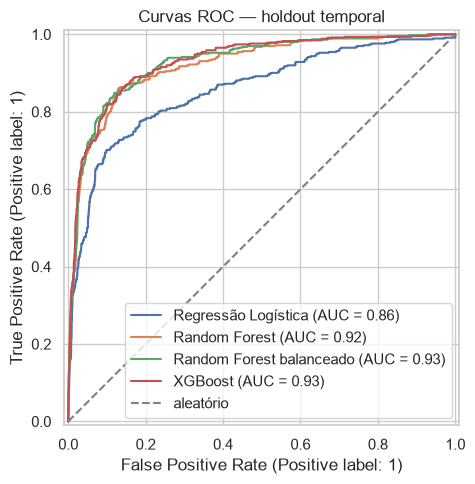

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))

for nome, probabilidade in probabilidades_validacao.items():
    RocCurveDisplay.from_predictions(
        y_valid,
        probabilidade,
        name=nome,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="aleatório")
ax.set_title("Curvas ROC — holdout temporal")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

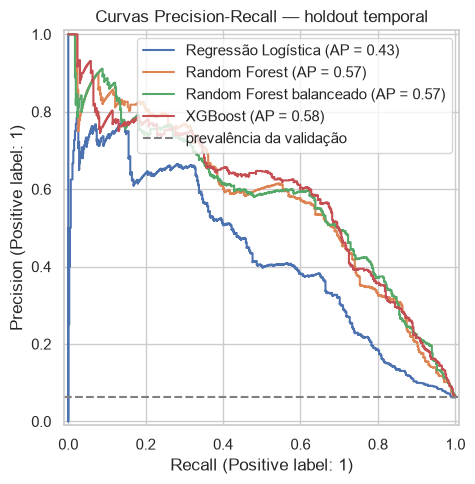

In [45]:
fig, ax = plt.subplots(figsize=(7, 5))

for nome, probabilidade in probabilidades_validacao.items():
    PrecisionRecallDisplay.from_predictions(
        y_valid,
        probabilidade,
        name=nome,
        ax=ax,
    )

ax.axhline(
    y_valid.mean(),
    linestyle="--",
    color="gray",
    label="prevalência da validação",
)
ax.set_title("Curvas Precision-Recall — holdout temporal")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 12.2. Efeito dos pesos no Random Forest

A comparação abaixo isola as duas configurações do mesmo algoritmo. Pesos podem alterar discriminação, mas também a escala das probabilidades; por isso, recall em limiar 0,5 não é usado como justificativa.

In [46]:
comparacao_pesos_rf = resultados_modelos.loc[
    resultados_modelos["modelo"].isin(
        ["Random Forest", "Random Forest balanceado"]
    )
].sort_values("Log Loss")

comparacao_pesos_rf

,modelo,configuracao,ROC-AUC,Log Loss,Average Precision,probabilidade_media,tempo_treinamento_seg
1,Random Forest,sem pesos,0.920540,0.144153,0.571888,0.066617,9.716840
2,Random Forest balanceado,"class_weight=""balanced""",0.928309,0.339570,0.574022,0.281608,12.657317


### 12.3. Resultado observado

O XGBoost apresentou o menor Log Loss (0,1333), além dos maiores ROC-AUC (0,9291) e Average Precision (0,5808), e foi selecionado neste holdout. O Random Forest sem pesos ficou próximo nas métricas de discriminação, mas teve Log Loss maior (0,1442). A Regressão Logística foi o modelo mais simples e rápido, porém apresentou resultados inferiores nas três métricas.

No Random Forest, `class_weight="balanced"` aumentou discretamente ROC-AUC e Average Precision, mas elevou a probabilidade média prevista para 28,16%, enquanto a taxa observada na validação foi 6,24%. O deslocamento piorou o Log Loss de 0,1442 para 0,3396. Portanto, os pesos não foram adotados: o ganho de discriminação não compensou a perda na qualidade probabilística.

In [47]:
modelo_selecionado = ranking_modelos.loc[0, "modelo"]
configuracao_selecionada = ranking_modelos.loc[0, "configuracao"]

print(f"Modelo selecionado: {modelo_selecionado}")
print(f"Configuração: {configuracao_selecionada}")
ranking_modelos.head(1)

Modelo selecionado: XGBoost
Configuração: sem pesos


,modelo,configuracao,ROC-AUC,Log Loss,Average Precision,probabilidade_media,tempo_treinamento_seg
0,XGBoost,sem pesos,0.929133,0.133252,0.580801,0.052203,3.030304


A seleção vale para este único holdout temporal. Ela não comprova calibração perfeita, estabilidade em outros períodos ou prontidão para produção.

## 13. Refinamento do modelo

O ajuste de hiperparâmetros não é realizado nesta etapa. A comparação anterior utiliza configurações fixas e moderadas no mesmo holdout temporal. Qualquer refinamento futuro deverá preservar a validação temporal e ser comparado ao XGBoost atual sem reutilizar a base de teste.

## 14. Previsões no Conjunto de Teste

Após o processo de seleção (Seção 12) e fine tuning do modelo (Seção 13), o Random Forest (`best_rf`) ajustado foi escolhido como modelo final por apresentar o melhor desempenho tanto em AUC-ROC quanto em Log Loss, além de boa estabilidade sob validação cruzada.

Nesta seção, utilizamos o modelo final para gerar as probabilidades de inadimplência para o conjunto de teste fornecido. Como a métrica solicitada no case é a probabilidade estimada de inadimplência, utilizamos `predict_proba` para obter o valor contínuo entre 0 e 1.


### 14.1. Treinamento do Modelo Final no Conjunto Completo de Desenvolvimento

Agora que a escolha do modelo foi concluída, treinamos o `best_rf` em todos os dados de desenvolvimento (X e y).

In [61]:
# Treina o modelo best_rf em todos os dados de desenvolvimento
best_rf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['ID_CLIENTE','SAFRA_REF','DATA_EMISSAO_DOCUMENTO',...,'SAFRA_ANO', 'SAFRA_MES','TAXA_RELATIVA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

### 14.2. Probabilidades de Inadimplência no Conjunto de Teste

In [62]:
# Gera as probabilidades de inadimplência no conjunto de teste
test_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Mostra as primeiras previsões para conferência
test_pred_proba[:10]

array([0.13233301, 0.00829091, 0.0092    , 0.0092    , 0.04166363,
       0.04166363, 0.04769425, 0.04569425, 0.06956914, 0.0757502 ])

### 14.3. Construção do Arquivo de Submissão

In [63]:
# Organiza as probabilidades em um DataFrame para submissão
submission = pd.DataFrame({
    'ID_CLIENTE': test_full['ID_CLIENTE'],
    'SAFRA_REF': test_full['SAFRA_REF'],
    'PROBABILIDADE_INADIMPLENCIA': test_pred_proba
})

submission.head()

,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.132333
1,274692171162531764,2021-07,0.008291
2,274692171162531764,2021-07,0.009200
3,274692171162531764,2021-07,0.009200
4,465309249432033993,2021-07,0.041664


### 14.4. Geração do Arquivo CSV para Submissão

In [64]:
submission.to_csv('submissao_case.csv', index = False)

### 14.5. Conclusão

As probabilidades foram geradas utilizando o modelo Random Forest ajustado, treinado em 100% da base de desenvolvimento. O arquivo de submissão segue o formato solicitado e contém, para cada registro do conjunto de teste, a probabilidade estimada de inadimplência. Este arquivo representa a entrega final do case técnico.

## 15. Considerações Finais

O objetivo deste case foi desenvolver um modelo capaz de estimar a probabilidade de inadimplência após uma cobrança, utilizando as bases de dados fornecidas: pagamentos, cadastro e informações mensais por cliente. Ao longo do projeto, construímos um fluxo completo de ciência de dados, incluindo consolidação das bases, análise exploratória, tratamento de dados, feature engineering, modelagem, validação e seleção do modelo final.

A análise exploratória confirmou um forte desbalanceamento da variável-alvo e revelou padrões consistentes entre características cadastrais, valor das cobranças e comportamento de pagamento. Após a construção das features e do pré-processamento, avaliamos três modelos principais: Regressão Logística, XGBoost e Random Forest. O Random Forest destacou-se com o maior AUC-ROC e o menor Log Loss, especialmente apresentando ótima performance na classe minoritária.

Com base nesse resultado, aplicamos validação cruzada e ajuste leve de hiperparâmetros para verificar a estabilidade do modelo e aprimorar seu desempenho. O modelo final demonstrou consistência e robustez, mantendo AUC em torno de 0.96.

Por fim, utilizamos o modelo ajustado para gerar as probabilidades de inadimplência no conjunto de teste disponibilizado, produzindo o arquivo final `submissao_case.csv` de submissão, conforme solicitado no case.

## 16. Referências

[1] *Scikit-Learn Documentation.* Disponível em: https://scikit-learn.org/stable/documentation.html.

[2] GÉRON, A. **Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras e TensorFlow.** 2ª ed. Rio de Janeiro: Alta Books, 2021.  

[3] KLOSTERMAN, S. **Projetos de Ciência de Dados com Python.** São Paulo: Novatec, 2020.